In [1]:
import pandas as pd

df = pd.read_csv(r"F:\EARTH_SYSTEM_ML_PROJECT\data\raw\pbdb\pbdb_fossils.csv",
                 low_memory=False)

In [2]:
df = df.dropna(subset=["early_interval", "lat", "lng", "accepted_name"])

taxon_col = "accepted_name"

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["time_encoded"] = le.fit_transform(df["early_interval"])

In [4]:
eco = df.groupby("early_interval").agg(
    richness=(taxon_col, "nunique"),
    occurrences=("occurrence_no", "count"),
    lat_mean=("lat", "mean"),
    lng_mean=("lng", "mean"),
    time_encoded=("time_encoded", "mean")
).reset_index()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [6]:
X = eco[["occurrences", "lat_mean", "lng_mean", "time_encoded"]]
y = eco["richness"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
from sklearn.metrics import r2_score, mean_absolute_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2 Score: 0.7713269879218396
MAE: 17.151176470588233


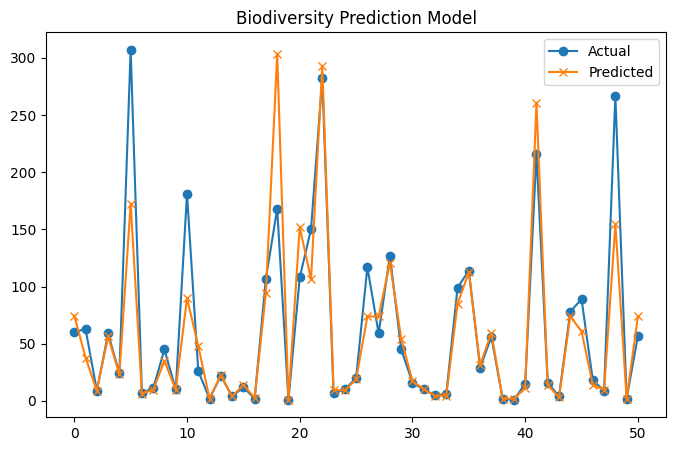

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual", marker="o")
plt.plot(pred, label="Predicted", marker="x")
plt.legend()
plt.title("Biodiversity Prediction Model")
plt.show()

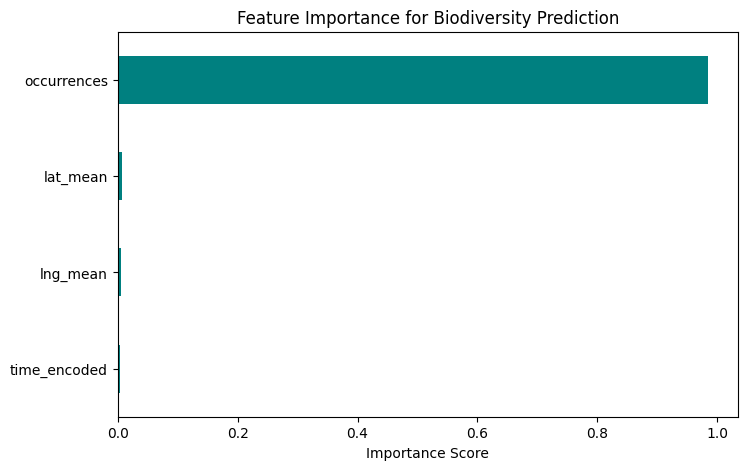

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8,5))
importance.plot(kind="barh", color="teal")
plt.title("Feature Importance for Biodiversity Prediction")
plt.xlabel("Importance Score")
plt.show()